In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmcrameri as cm
import cmocean as cmc

import cloud_filtering.training.config as config
import cloud_filtering.plotting.utils as plot_utils

plt.style.use('../plotstyling.mplstyle')

In [3]:
# TODO: replace with quantiles from config
quantiles = config.QUANTILES

Ta_bins = np.linspace(100, 300, 50)
deviation_bins = np.linspace(-30, 30, 101)  # bins used for calculating distributions of predicted error
cloud_signal_bins = np.linspace(-15, 160, 176)
cloud_signal_bins_narrower = np.linspace(-2, 10, 121)
lat_bins = np.arange(-90, 91, 1)
lon_bins = np.arange(-180, 181, 1)

fwp_bins = np.logspace(-5, 1, 100)
tcwv_bins = np.linspace(0, 20, 100)

lat_centres = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lon_centres = 0.5 * (lon_bins[:-1] + lon_bins[1:])
deviation_bins_centre = deviation_bins[:-1] + np.diff(deviation_bins) / 2
cloud_signal_bins_centre = cloud_signal_bins[:-1] + np.diff(cloud_signal_bins) / 2
cloud_signal_bins_narrower_centre = cloud_signal_bins_narrower[:-1] + np.diff(cloud_signal_bins_narrower) / 2

blues = plt.cm.Blues(np.linspace(0.3, 0.9, 6))
oranges = plt.cm.Oranges(np.linspace(0.9, 0.3, 4))

In [4]:
ds = xr.open_dataset("../../../DataStorage/AWS/for_cloud_filtering/test_set_retrievals/cloud_signal_test_set_retrievals_aws31_36_20260304.nc")

Fwp = ds.Fwp.values
Latitude = ds.Latitude.values
Longitude = ds.Longitude.values

channels = ["AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

surface_mask = ds.surface_mask.values

In [5]:
filename = "../../../DataStorage/AWS/for_cloud_filtering/training_splits/aws_database_2026-02-27_test.nc"
filename_db = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
#filename = "../../../DataStorage/AWS/Arctic/combined_v3.nc"
ds_test_data = xr.open_dataset(filename)
full_db = xr.open_dataset(filename_db)


In [23]:
ds_test_data

<xarray.Dataset> Size: 313MB
Dimensions:            (number: 1564202)
Dimensions without coordinates: number
Data variables: (12/25)
    Ta_Allsky_AWS31    (number) float64 13MB ...
    Ta_Allsky_AWS32    (number) float64 13MB ...
    Ta_Allsky_AWS33    (number) float64 13MB ...
    Ta_Allsky_AWS34    (number) float64 13MB ...
    Ta_Allsky_AWS35    (number) float64 13MB ...
    Ta_Allsky_AWS36    (number) float64 13MB ...
    ...                 ...
    Ta_Clearsky_AWS43  (number) float64 13MB ...
    Ta_Clearsky_AWS44  (number) float64 13MB ...
    CloudSat_Datetime  (number) datetime64[ns] 13MB ...
    Latitude           (number) float64 13MB ...
    Longitude          (number) float64 13MB ...
    Fwp                (number) float64 13MB ...
Attributes:
    created_with:  easy_arts 9e302fdeeb61569e1523e03a4711f6de562fe2da (dirty)

In [13]:
true = ds[f"CloudSignal_AWS33_true"]
mean = ds[f"CloudSignal_AWS33_mean"]

deviation = 100 * (mean - true) / true


#sel_condition = np.abs(deviation) > error_threshold
sel_condition = mean > 2
sel_condition = sel_condition & (true < -0.01) & (true > -0.014)

selected_scene_idxs = np.where(
        (full_db.CloudSat_Datetime.values == ds.CloudSat_Datetime.values[sel_condition][1])
        & (full_db.Longitude < -30)
    )[0]

In [14]:
print(sel_condition)

<xarray.DataArray (number: 726519)> Size: 727kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * number   (number) int64 6MB 0 1 2 3 4 ... 726514 726515 726516 726517 726518


In [15]:
BASE_INPUT_VARIABLES = [
    "Ta_Allsky_AWS31",
    "Ta_Allsky_AWS32",
    "Ta_Allsky_AWS33",
    "Ta_Allsky_AWS34",
    "Ta_Allsky_AWS35",
    "Ta_Allsky_AWS36",
    "Ta_Allsky_AWS41",
    "Ta_Allsky_AWS42",
    "Ta_Allsky_AWS43",
    "Ta_Allsky_AWS44",
    "MirrorAngle",
]

BASE_OUTPUT_VARIABLES = [
    "CloudSignal_AWS31",
    "CloudSignal_AWS32",
    "CloudSignal_AWS33",
    "CloudSignal_AWS34",
    "CloudSignal_AWS35",
    "CloudSignal_AWS36",
    "CloudSignal_AWS41",
    "CloudSignal_AWS42",
    "CloudSignal_AWS43",
    "CloudSignal_AWS44",
]


VARIANTS = {
    "aws31_36": [],
    "aws32_36": ["Ta_Allsky_AWS31"],
    "aws33_36": ["Ta_Allsky_AWS31", "Ta_Allsky_AWS32"],
    "aws34_36": ["Ta_Allsky_AWS31", "Ta_Allsky_AWS32", "Ta_Allsky_AWS33", "Ta_Allsky_AWS44"],
    "aws35_36": ["Ta_Allsky_AWS31", "Ta_Allsky_AWS32", "Ta_Allsky_AWS33", "Ta_Allsky_AWS44", "Ta_Allsky_AWS34", "Ta_Allsky_AWS43"],
}


def get_input_variables(tag):
    """Return input list for a given variant."""
    drop = set(VARIANTS[tag])
    inputs = [v for v in BASE_INPUT_VARIABLES if v not in drop]

    # never train if only AWS36 remains from AWS3x
    #aws3x = [v for v in inputs if v.startswith("Ta_Allsky_AWS3")]
    #if aws3x == ["Ta_Allsky_AWS36"]:
    #    raise ValueError("Invalid variant: only AWS36 remaining.")

    return inputs

def get_output_variables(tag):
    """Return input list for a given variant."""
    drop = set(VARIANTS[tag])
    print(drop)
    outputs = []
    for var in BASE_OUTPUT_VARIABLES:
        print(var)
        var_allsky = f"Ta_Allsky_AWS{var[-2:]}"
        if var_allsky not in drop:
            outputs.append(var)

    return outputs


33


/tmp/ipykernel_106091/291607091.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


34


/tmp/ipykernel_106091/291607091.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


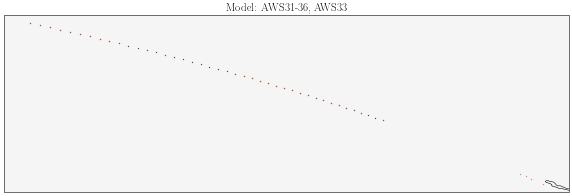

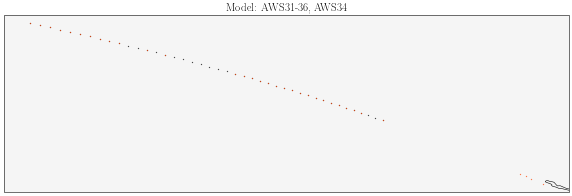

In [16]:
error_threshold = 100

for i, variant in enumerate(config.VARIANTS):

    if variant != "aws31_36":
        continue

    variant_inputs = list(set(config.BASE_INPUT_VARIABLES[:-1]).difference(config.VARIANTS[variant]))
    variant_outputs = [f'CloudSignal_{var[-5:]}' for var in variant_inputs]
    variant_outputs = np.sort(variant_outputs)
    n_output_variables = len(variant_outputs)
    channel_ids = np.array([int(var[-2:]) for var in variant_outputs])
    
    n_group_3 = np.sum(channel_ids < 40) # for removing axes
    n_group_4 = np.sum(channel_ids > 40)

    
    for i, var in enumerate(variant_outputs):

        channel = var[-5:]
        channel_id = int(var[-2:])

        if (channel_id != 33) & (channel_id != 34):
            continue
        print(channel_id)

        fig, ax = plt.subplots(1, 1, figsize=(30, 5),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                                constrained_layout=True)

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.set_facecolor("whitesmoke")

        true = ds[f"CloudSignal_AWS33_true"]
        mean = ds[f"CloudSignal_AWS33_mean"]
        
        deviation = 100 * (mean - true) / true
        
        lat = ds.Latitude.values
        lon = ds.Longitude.values

        ax.scatter(
            full_db.Longitude[selected_scene_idxs],
            full_db.Latitude[selected_scene_idxs ],
            s=2,                    # marker size
            color="k",
            alpha=0.6,
            transform=ccrs.PlateCarree()
        )

        ax.scatter(
            lon[sel_condition],
            lat[sel_condition],
            s=2,                    # marker size
            color="orangered",
            alpha=0.6,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(
            f"Model: {variant.replace('_','-').upper()}, {channel}"
        )

        fig.tight_layout()
        
        plt.savefig(f"../figures/test_set_retrievals/global_distributions/AWS_cloudfilter_map_surface_issue_{channel}.png", dpi=200, bbox_inches="tight", facecolor="white")

    ds.close()

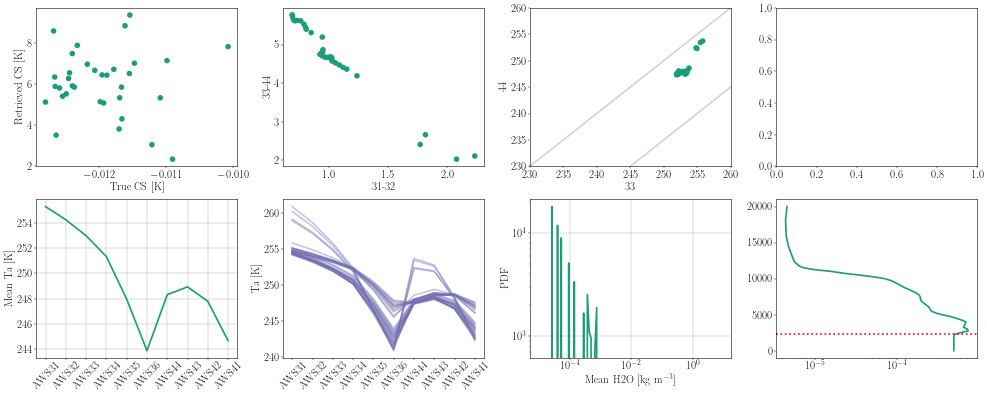

In [22]:

fig, axes = plt.subplots(2, 4, figsize=(25,10))

axes[0,0].scatter(true[sel_condition], mean[sel_condition])
axes[0,0].set_xlabel("True CS [K]")
axes[0,0].set_ylabel("Retrieved CS [K]")

#axes[0,1].plot([230, 260], [230, 260], c="lightgrey")
#axes[0,1].plot([230, 260], [215, 245], c="lightgrey")
axes[0,1].scatter(ds.Ta_Allsky_AWS31[sel_condition]-ds.Ta_Allsky_AWS32[sel_condition], ds.Ta_Allsky_AWS33[sel_condition]-ds.Ta_Allsky_AWS44[sel_condition])
axes[0,1].set_xlabel("31-32")
axes[0,1].set_ylabel("33-44")
axes[0,2].set_xlim([230, 260])
axes[0,2].set_ylim([230, 260])
axes[0,2].plot([230, 260], [230, 260], c="lightgrey")
axes[0,2].plot([230, 260], [215, 245], c="lightgrey")
axes[0,2].scatter(ds.Ta_Allsky_AWS33[sel_condition], ds.Ta_Allsky_AWS44[sel_condition])
axes[0,2].set_xlabel("33")
axes[0,2].set_ylabel("44")

numer = ds[f"Ta_Allsky_AWS44"].values[sel_condition]*ds[f"Ta_Allsky_AWS34"].values[sel_condition]
denom = ds[f"Ta_Allsky_AWS33"].values[sel_condition]*ds[f"Ta_Allsky_AWS43"].values[sel_condition]

#axes[0,3].scatter(ds.Ta_Allsky_AWS31[sel_condition]-ds.Ta_Allsky_AWS32[sel_condition], numer/denom)


mean_Ta_by_channel = np.mean(Ta_array[sel_condition], axis=0)

axes[1,0].plot(np.arange(0,10, 1), mean_Ta_by_channel)
axes[1,0].grid()
axes[1,0].set_xticks(np.arange(0,10, 1))
axes[1,0].set_xticklabels(channels)
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].set_ylabel("Mean Ta [K]")


for i in range(Ta_array[sel_condition].shape[0]):
    
    axes[1,1].plot(np.arange(0,10, 1), Ta_array[sel_condition][i], c="C2", alpha=0.4)
    axes[1,1].grid()
    axes[1,1].set_xticks(np.arange(0,10, 1))
    axes[1,1].set_xticklabels(channels)
    axes[1,1].tick_params(axis="x", rotation=45)
    axes[1,1].set_ylabel("Ta [K]")

fwp_counts, _ = np.histogram(Fwp[sel_condition], bins=fwp_bins, density=True)

axes[1,2].plot(fwp_bins[:-1], fwp_counts)
axes[1,2].set_yscale("log")
axes[1,2].set_xscale("log")
axes[1,2].grid()
axes[1,2].set_xlabel("FWP")
axes[1,2].set_ylabel("PDF")

tcwv_counts, _ = np.histogram(full_db.H2O_Column[selected_scene_idxs], bins=tcwv_bins, density=True)

#axes[1,3].plot(tcwv_bins[:-1], tcwv_counts)
#axes[1,3].set_yscale("log")
#axes[1,3].set_xscale("log")

mean_h2o_by_altitude = np.mean(full_db.H2O.values[selected_scene_idxs], axis=0)

axes[1,3].plot(mean_h2o_by_altitude, full_db.vertical_level)
axes[1,3].axhline(np.mean(full_db.Surf_Z.values[selected_scene_idxs]), ls=":", c="red", label="Mean z")
axes[1,3].set_xscale("log")
axes[1,2].set_xlabel("Mean H2O [kg m$^{-3}$]")

fig.tight_layout()

ds.close()

In [18]:
full_db.Surf_Z.values[selected_scene_idxs]

array([2404.4126297 , 2431.3024496 , 2442.08621746, 2449.57342562,
       2460.0857758 , 2469.38195041, 2474.46207806, 2472.74123721,
       2462.43438645, 2448.63392168, 2430.04735665, 2391.5573468 ,
       2339.1946064 , 2298.0239409 , 2279.10315178, 2262.71136515,
       2240.01285764, 2218.63032305, 2200.31766163, 2186.18842889,
       2176.37227177, 2170.83809468, 2170.31411816, 2175.15248522,
       2182.90344544, 2191.22193276, 2200.20639501, 2210.68099556,
       2223.44067902, 2237.1199945 , 2251.13668983, 2263.22715872,
       2272.98625693, 2279.65982047, 2283.59522215, 2285.73701086,
       2289.17403813, 2295.5022111 , 2299.71129167, 2305.15942905,
       2314.18876159, 2325.07933162])

In [24]:
 ds[f"Ta_Allsky_AWS31"][sel_condition] -  ds[f"Ta_Allsky_AWS44"][sel_condition]

<xarray.DataArray (number: 34)> Size: 272B
array([7.19882598, 6.77959901, 6.51243668, 6.84805342, 6.99558953,
       6.95925626, 6.9316092 , 6.91728848, 6.89567209, 6.87704932,
       6.89152897, 6.92856575, 6.95058488, 6.9364863 , 6.87010438,
       6.82133977, 6.80078081, 6.79217431, 6.79084593, 6.8298005 ,
       6.90589802, 6.96010046, 7.25495531, 7.14525665, 7.12691664,
       7.15971314, 7.20761277, 7.23002198, 7.16762558, 7.10683005,
       7.10686387, 7.16559345, 7.19924702, 7.19825629])
Coordinates:
  * number   (number) int64 272B 460443 460445 460446 ... 460507 460508 460509